# Teste de granularidade para modelos de ML

## Bibliotecas

In [20]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from keras.models import Model
from keras.layers import Input, Dense, GRU as GRU_layer, LSTM as LSTM_layer, SimpleRNN as RNN_layer
from keras.layers import Flatten,  Dropout
from tensorflow import cast, float32,reduce_mean,maximum
import tensorflow as tf
from keras.backend import epsilon
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle
import optuna
import pmdarima as pm
import itertools


## carregando os dados

In [68]:


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_day'
#tempo_dia = pd.read_csv('../../data/times/times_1_day.csv')
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
# 2. Use glob to get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_dia = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_dia.append(df)

    #print(f"Loaded '{file}' as dataframe '{filename}'")

# --- Now you can access any dataframe by its filename ---
df_day = pd.concat(lista_dia, ignore_index=True)
del lista_dia
print("\n--- All dataframes loaded successfully! ---")


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_hour'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_hora = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_hora.append(df)
df_hour = pd.concat(lista_hora, ignore_index=True)
del lista_hora
# --- Now you can access any dataframe by its filename ---
print("\n--- All dataframes loaded successfully! ---")



# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_10_minutes'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_min = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = os.path.splitext(os.path.basename(file))[0]
    
    
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_min.append(df)

# --- Now you can access any dataframe by its filename ---
df_10min = pd.concat(lista_min, ignore_index=True)
del lista_min
print("\n--- All dataframes loaded successfully! ---")

1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---


## Analise exploratória para redução de dados
Ao fazer a analise, entende-se que os dados possuem variancias bem distintas e escolhe-se alguns exemplares para fazer os experimentos


Instituições com poucos dados: 5
Instituições com pelo menos 1 nulo: 0
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 111
Instituições restantes: 167


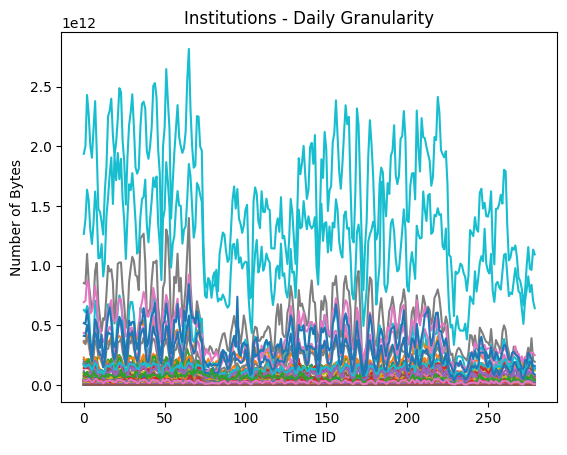

In [69]:
import matplotlib.pyplot as plt
import numpy as np
#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.10)
    Q3 = instituicao["n_bytes"].quantile(0.90)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1

    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        #print(f"{i} tem outliers")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com pelo menos 1 nulo: {val_null}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")

for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]
  
print()

## Funções tratamento e separação de dados

In [9]:


def treino_val_teste(df = pd.Series, t_treino = 0, t_teste = 0, t_val = 0):
    return  df[:int(t_treino*len(df))], df[int(t_treino*len(df)):int((t_treino + t_val)*len(df))]  , df[int((t_treino + t_val)*len(df)):]

def scaling(df_series: pd.Series, mode = 0, scaler = None) -> pd.Series:
    if mode == 0:
        scaler = MinMaxScaler()
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.fit_transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name),scaler
    elif mode == 1:
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name)     

def sliding_window (df_series: pd.Series, inputs: int, outputs: int):

    total_window_size = inputs + outputs
    
    # 1. Validação
    if len(df_series) < total_window_size:
        print(f"Erro: Tamanho dos dados ({len(df_series)}) é menor que a janela total ({total_window_size})")
        return pd.DataFrame() # Retorna um DataFrame vazio

    # 2. Cria as janelas (sliding windows)
    windowed_data = []
    # Itera do primeiro índice inicial possível até o último
    for i in range(len(df_series) - total_window_size + 1):
        # A fatia vai de 'i' até 'i + tamanho_total'
        window_slice = df_series.iloc[i : i + total_window_size].values
        windowed_data.append(window_slice)

    # 3. Define os nomes das colunas
    x_cols = [f"x_{j}" for j in range(inputs)]
    y_cols = [f"y_{o}" for o in range(outputs)]
    
    # 4. Cria o DataFrame final
    df_windowed = pd.DataFrame(windowed_data, columns=x_cols + y_cols)
    return df_windowed


## Tratando [DIA] e separando em treino, val e teste

In [7]:


inputs_day = 7
outputs_day = 1
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]
train_list = []
val_list = []
test_list = []
#inst = inst_hour #SÓ DESCOMENTE ISSO DEPOIS DE TER RODADO A CELULA DE HORAS
for i in inst:
    print(i)
    serie = pd.Series(df_day[df_day["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_day + outputs_day):
        _train_day, _val_day, _test_day  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_day,scaler = scaling(_train_day,0)
        test_day = scaling(_test_day,1,scaler)
        val_day = scaling(_val_day,1,scaler)
        train_day_ = sliding_window(df_series = train_day, inputs = inputs_day, outputs = outputs_day)
        train_day_.insert(0, "id_institution", i)
        train_list.append(train_day_)

        test_day_ = sliding_window(df_series = test_day, inputs = inputs_day, outputs = outputs_day)
        test_day_.insert(0, "id_institution", i)
        test_list.append(test_day_)

        val_day_ = sliding_window(df_series = val_day, inputs = inputs_day, outputs = outputs_day)
        val_day_.insert(0, "id_institution", i)
        val_list.append(val_day_)

    else: print(f"   dataset pequeno ({tamanho})")
train_day_wind = pd.concat(train_list, ignore_index=True)
val_day_wind = pd.concat(val_list, ignore_index=True)
test_day_wind = pd.concat(test_list, ignore_index=True)
inst_day = list(train_day_wind["id_institution"].unique())
print("\n\n" + str(len(inst_day)))
del train_list, val_list, test_list
train_day_wind.to_csv('../../data/Tabelas_criadas/treino_dia.csv', index = False)
test_day_wind.to_csv('../../data/Tabelas_criadas/teste_dia.csv', index = False)
val_day_wind.to_csv('../../data/Tabelas_criadas/val_dia.csv', index = False)


252
98
73
93
239
60
113
27
74
53
147
193
240
40
130
230
62
179
102
12
71
205
161
6
83
132
100
149
117
156
41
165
222
39
84
190
224
0
155
9
169
52
158
143
254
34
173
107
138
208
32
86
137
57
201
192
105
50
168
223
64
119
55
196
167
10
80
79
178
246
180
145
213
115
220
238
16
111
164
175
72
5
25
123
76
152
232
48
207
70
4
216
31
151
68
54
95
218
133
46
214
112
106
35
215
244
120
104
235
183
243
24
67
42
172
38
56
225
228
217
219
191
94
82
200
144
118
63
22
23
75
45
65
141
101
126
114
203
108
136
284
88
28
3
109
30
8
221
150
125
177
198
248
66
249
171
59
189
69
185


160


## Tratando [HORAS] e separando em treino, val e teste

In [10]:


inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        train_hour_ = sliding_window(df_series = train_hour, inputs = inputs_hour, outputs = outputs_hour)
        train_hour_.insert(0, "id_institution", i)
        train_list.append(train_hour_)

        test_hour_ = sliding_window(df_series = test_hour, inputs = inputs_hour, outputs = outputs_hour)
        test_hour_.insert(0, "id_institution", i)
        test_list.append(test_hour_)

        val_hour_ = sliding_window(df_series = val_hour, inputs = inputs_hour, outputs = outputs_hour)
        val_hour_.insert(0, "id_institution", i)
        val_list.append(val_hour_)
    else: print(f"   dataset pequeno ({tamanho})")

train_hour_wind = pd.concat(train_list, ignore_index=True)
val_hour_wind = pd.concat(val_list, ignore_index=True)
test_hour_wind = pd.concat(test_list, ignore_index=True)


train_hour_wind.to_csv('../../data/Tabelas_criadas/treino_hora.csv', index = False)
test_hour_wind.to_csv('../../data/Tabelas_criadas/teste_hora.csv', index = False)
val_hour_wind.to_csv('../../data/Tabelas_criadas/val_hora.csv', index = False)

252
98
   dataset pequeno (0)
73
93
239
   dataset pequeno (0)
60
113
   dataset pequeno (0)
27
   dataset pequeno (0)
74
   dataset pequeno (0)
53
147
   dataset pequeno (0)
193
240
   dataset pequeno (0)
40
   dataset pequeno (0)
130
   dataset pequeno (0)
230
   dataset pequeno (0)
62
179
   dataset pequeno (0)
102
   dataset pequeno (0)
12
   dataset pequeno (0)
71
   dataset pequeno (0)
205
161
   dataset pequeno (0)
6
   dataset pequeno (0)
83
   dataset pequeno (0)
132
   dataset pequeno (0)
100
   dataset pequeno (0)
149
117
   dataset pequeno (0)
156
41
165
   dataset pequeno (0)
222
39
84
190
   dataset pequeno (0)
224
   dataset pequeno (0)
0
   dataset pequeno (0)
155
   dataset pequeno (0)
9
   dataset pequeno (0)
169
52
   dataset pequeno (0)
158
   dataset pequeno (0)
143
254
34
173
   dataset pequeno (0)
107
   dataset pequeno (0)
138
   dataset pequeno (0)
208
   dataset pequeno (0)
32
   dataset pequeno (0)
86
   dataset pequeno (0)
137
57
   dataset pequeno (0)
201
1

## Tratando [MINUTOS] e separando em treino, val e teste
por enquano, este vai ficar de escanteio por precisar de um tratamento mais especifico


In [ ]:


inputs_10min = 2*24*6
outputs_10min = 1*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_10min[df_10min["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_10min,scaler = scaling(_train_hour,0)
        test_10min = scaling(_test_hour,1,scaler)
        val_10min = scaling(_val_hour,1,scaler)
        train_10min_ = sliding_window(df_series = train_10min, inputs = inputs_10min, outputs = outputs_10min)
        train_10min_["id_institution"] = i
        train_list.append(train_10min_)

        test_10min_ = sliding_window(df_series = test_10min, inputs = inputs_10min, outputs = outputs_10min)
        test_10min_["id_institution"] = i
        test_list.append(test_10min_)
        val_10min_ = sliding_window(df_series = val_10min, inputs = inputs_10min, outputs = outputs_10min)
        val_10min_["id_institution"] = i
        val_list.append(val_10min_)
    else: print(f"   dataset pequeno ({tamanho})")

train_10min_wind = pd.concat(train_list, ignore_index=True)
val_10min_wind = pd.concat(val_list, ignore_index=True)
test_10min_wind = pd.concat(test_list, ignore_index=True)
inst_10min = list(train_10min_wind["id_institution"].unique())
print("\n\n" + str(len(inst_10min)))


train_10min_wind.to_csv('../../data/Tabelas_criadas/treino_10min.csv', index = False)
test_10min_wind.to_csv('../../data/Tabelas_criadas/teste_10min.csv', index = False)
val_10min_wind.to_csv('../../data/Tabelas_criadas/val_10min.csv', index = False)

192
249
71
205
148
   dataset pequeno (0)
184
125
164
97
56


9


## Dados já carregados

In [2]:
train_hour_wind = pd.read_csv('../../data/Tabelas_criadas/treino_hora.csv')
test_hour_wind = pd.read_csv('../../data/Tabelas_criadas/teste_hora.csv')
val_hour_wind = pd.read_csv('../../data/Tabelas_criadas/val_hora.csv')
inputs_hour = 7*24
outputs_hour = 1*24

train_day_wind = pd.read_csv('../../data/Tabelas_criadas/treino_dia.csv')
test_day_wind = pd.read_csv('../../data/Tabelas_criadas/teste_dia.csv')
val_day_wind = pd.read_csv('../../data/Tabelas_criadas/val_dia.csv')
inputs_day = 7
outputs_day = 1

np_train_d = np.array(train_day_wind)
np_test_d = np.array(test_day_wind)
np_val_d = np.array(val_day_wind)
X_train_d = np_train_d[:, :inputs_day + 1].astype('float32')
y_train_d = np_train_d[:, inputs_day+1:].astype('float32')
X_test_d = np_test_d[:, :inputs_day + 1].astype('float32')
y_test_d = np_test_d[:, np.r_[inputs_day+1:inputs_day+1+y_train_d.shape[1],0]].astype('float32')
X_val_d = np_val_d[:, :inputs_day + 1].astype('float32')
y_val_d = np_val_d[:, inputs_day+1:].astype('float32')


np_train_h = np.array(train_hour_wind)
np_test_h = np.array(test_hour_wind)
np_val_h = np.array(val_hour_wind)
X_train_h = np_train_h[:, :inputs_hour + 1].astype('float32')
y_train_h = np_train_h[:, inputs_hour+1:].astype('float32')
X_test_h = np_test_h[:, :inputs_hour + 1].astype('float32')
y_test_h = np_test_h[:, np.r_[inputs_hour+1:inputs_hour+1+y_train_h.shape[1],0]].astype('float32')
X_val_h = np_val_h[:, :inputs_hour + 1].astype('float32')
y_val_h = np_val_h[:, inputs_hour+1:].astype('float32')

## Funções de modelos preditivos

In [28]:
# For Graphs plotting and training time evaluation
import pylab as plt

def generate_GRU(n_timesteps, n_features, n_outputs, dropout_rate=0.2, gru_units=64):
    """
    Cria um modelo GRU puro.
    
    n_timesteps: Comprimento da sequência temporal (no seu caso, 1)
    n_features: Quantidade de colunas/variáveis de entrada
    n_outputs: Quantidade de valores a prever
    """
    
    # Camada de Entrada
    inp = Input(shape=(n_timesteps, n_features))
    x = GRU_layer(gru_units, return_sequences=False)(inp) 
    
    # Dropout para evitar overfitting
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    
    model = Model(inputs=inp, outputs=out)
    return model



from statsmodels.tsa.statespace.sarimax import SARIMAX

def generate_SARIMA_model(order, seasonal_order, X_train):
    """
    Cria um modelo SARIMA com os parâmetros fornecidos.
    
    order: tupla (p,d,q)
    seasonal_order: tupla (P,D,Q,s)
    X_train: série temporal de treino
    """
    model = SARIMAX(
        X_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model

def generate_MLP_model(max_seq, output):
    ip = Input(shape=(max_seq,))
    y= Dropout(0.1)(ip)
    y = Flatten()(y)
    y = Dense(500, activation='relu')(y)
    y = Dropout(0.2)(y)
    y = Dense(500, activation='relu')(y)
    y = Dropout(0.2)(y)
    y = Dense(500, activation = 'relu')(y)
    y = Dropout(0.3)(y)
    out = Dense(output, activation='linear')(y)
    model = Model(ip, out)
    model.summary()
    return model

def generate_LSTM(n_timesteps, 
                  n_features, 
                  n_outputs, 
                  dropout_rate=0.2, 
                  lstm_units=64
                  ):
    inp = Input(shape=(n_timesteps, n_features))
    x = LSTM_layer(lstm_units, return_sequences=False)(inp) 
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    return model

def generate_RNN(n_timesteps, 
                 n_features, 
                 n_outputs, 
                 dropout_rate=0.2, 
                 rnn_units=64
                 ):
    inp = Input(shape=(n_timesteps, n_features))
    x = RNN_layer(rnn_units, return_sequences=False)(inp) 
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    return model

def get_nrmse(global_range):
    def nrmse(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Calcular o RMSE matematicamente
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        rmse = tf.sqrt(mse)
        
        # Usa a amplitude global fixa em vez de calcular por lote!
        return rmse / global_range
    
    # Renomeia a função interna para ficar bonito no log do Keras
    nrmse.__name__ = 'nrmse'
    return nrmse

def smape(y_true, y_pred):
    y_true = cast(y_true, float32)
    y_pred = cast(y_pred, float32)
    diff = abs(y_true - y_pred)
    add = abs(y_true) + abs(y_pred)
    # epsilon é usado para evitar divisão por zero
    return 100.0 * reduce_mean(diff / maximum(add, epsilon()))

In [38]:
def criar_e_treinarMLP(dimensao,
                       input_len, 
                       output_len,
                       X_train,y_train, 
                       X_val, 
                       y_val, 
                       epochs, 
                       batch_size, 
                       path_modelo = None, 
                       path_metricas = None,
                       plot = True,):
    print("criando modelo...")
    mlp = generate_MLP_model(input_len,output_len)
    print("compilando modelo...")
    mlp.compile(
        optimizer='adam',
        loss='mean_squared_error', # Para regressão, a perda é o MSE
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse,
                smape
            ]
    )
    print("treinando modelo...")
    history = mlp.fit(
        X_train, 
        y_train, 
        epochs=epochs, # Comece com poucas epochs (ex: 10) e aumente se necessário
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=1 # Mostra a barra de progresso
    )
    print(
        f"modelo treinado!\
        \nResultado:\
        \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
        \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
        \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
        \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
          )
    
    if plot:
        plt.title(label= 'MLP Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='MLP Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='MLP Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='MLP Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        mlp.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": "MLP"
            ,"DIM": dimensao
            ,"RMSE": history.history["val_rmse"][-1]
            ,"MAE": history.history["val_mae"][-1]
            ,"NMRSE": history.history['val_nrmse'][-1]
            ,"SMAPE": history.history['val_smape'][-1]
            }

        df = pd.DataFrame(dict_model).set_index("idx")
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarGRU(dimensao,
                       input_len, 
                       output_len,
                       X_train,
                       y_train,
                        X_val,
                        y_val,
                        epochs,
                        batch_size,
                        dropout_rate, 
                        gru_units, 
                        path_modelo = None, 
                        path_metricas = None,
                        plot = True,
                        verbose = True):
    print("criando modelo...")
    gru = generate_GRU(1,input_len,output_len, dropout_rate, gru_units)

    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())

    gru.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    if len(X_train.shape) == 2:
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
        X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = gru.fit(
        X_train, 
        y_train, 
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'GRU Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='GRU Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='GRU Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='GRU Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        gru.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": ["GRU"]
            ,"DIM": [dimensao]
            ,"RMSE": [history.history["val_rmse"][-1]]
            ,"MAE": [history.history["val_mae"][-1]]
            ,"NMRSE": [history.history['val_nrmse'][-1]]
            ,"SMAPE": [history.history['val_smape'][-1]]
            }

        df = pd.DataFrame(dict_model)
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarLSTM(dimensao,
                       input_len, 
                       output_len,
                       X_train,
                       y_train,
                        X_val,
                        y_val,
                        epochs,
                        batch_size,
                        dropout_rate, 
                       lstm_units, 
                       path_modelo = None, 
                       path_metricas = None,
                       plot = True,
                       verbose = True):
    print("criando modelo...")
    lstm = generate_LSTM(1,input_len, output_len, dropout_rate, lstm_units)

    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())

    lstm.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    if len(X_train.shape) == 2:
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
        X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = lstm.fit(
        X_train, 
        y_train, 
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'LSTM Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='LSTM Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='LSTM Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='LSTM Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        lstm.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": ["LSTM"]
            ,"DIM": [dimensao]
            ,"RMSE": [history.history["val_rmse"][-1]]
            ,"MAE": [history.history["val_mae"][-1]]
            ,"NMRSE": [history.history['val_nrmse'][-1]]
            ,"SMAPE": [history.history['val_smape'][-1]]
            }

        df = pd.DataFrame(dict_model)
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarRNN(dimensao,
                          input_len, 
                          output_len,
                          X_train,
                          y_train,
                            X_val,
                            y_val,
                            epochs,
                            batch_size,
                            dropout_rate, 
                          rnn_units, 
                          path_modelo = None, 
                          path_metricas = None,
                          plot = True,
                          verbose = True):
    print("criando modelo...")
    rnn = generate_RNN(
         n_timesteps = 1,
         n_features=input_len,
         n_outputs = output_len,
         dropout_rate = dropout_rate,
         rnn_units = rnn_units
    )
    
    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())
    
    rnn.compile(
          optimizer='adam',
          loss='mean_squared_error',
          metrics=[
                 RootMeanSquaredError(name='rmse'),
                 MeanAbsoluteError(name='mae'),
                 get_nrmse(amplitude_global),
                 smape
                ]
     )
    if len(X_train.shape) == 2:
          X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
          X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = rnn.fit(
          X_train, 
          y_train, 
          epochs=epochs,
          batch_size=batch_size,
          validation_data=(X_val, y_val),
          verbose=0
     )
    if verbose:
          print(
                f"modelo treinado!\
                \nResultado:\
                \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
                \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
                \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
                \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
                )
     
    if plot:
          plt.title(label= 'RNN Val RMSE')
          plt.plot(history.history['val_rmse'])
          plt.show()
          plt.title(label='RNN Val MAE')
          plt.plot(history.history['val_mae'])
          plt.show()
          plt.title(label='RNN Val NRMSE')
          plt.plot(history.history['val_nrmse'])
          plt.show()
          plt.title(label='RNN Val SMAPE')
          plt.plot(history.history['val_smape'])
          plt.show()
    if path_modelo is not None:
          rnn.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
            dict_model ={
                "idx": 0
                ,"MODELO": ["RNN"]
                ,"DIM": [dimensao]
                ,"RMSE": [history.history["val_rmse"][-1]]
                ,"MAE": [history.history["val_mae"][-1]]
                ,"NMRSE": [history.history['val_nrmse'][-1]]
                ,"SMAPE": [history.history['val_smape'][-1]]
                }
    
            df = pd.DataFrame(dict_model)
            header_condition = not os.path.exists(path_metricas)
            df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

## Treinando os modelos

In [39]:
def otimizar_GRU(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        gru_units = trial.suggest_int('gru_units', 32, 128)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarGRU(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                dropout_rate=dropout_rate,
                gru_units=gru_units,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_GRU")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarGRU(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        dropout_rate=study.best_params['dropout_rate'],
        gru_units=study.best_params['gru_units'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

def otimizar_LSTM(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        lstm_units = trial.suggest_int('lstm_units', 32, 128)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarLSTM(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                dropout_rate=dropout_rate,
                lstm_units=lstm_units,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_LSTM")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarLSTM(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        dropout_rate=study.best_params['dropout_rate'],
        lstm_units=study.best_params['lstm_units'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

def otimizar_RNN(X_train,
                    y_train, 
                    X_val, 
                    y_val, 
                    dimensao, 
                    input_len, 
                    output_len,
                    path_modelo = None):
        
        def objective(trial):
            # 1. Definir o espaço de busca que será passado para a sua função
            # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            epochs = trial.suggest_int('epochs', 10, 30, step=10)
            dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
            rnn_units = trial.suggest_int('rnn_units', 32, 128)
            
            try:
                # Chama a SUA função
                history = criar_e_treinarRNN(
                    dimensao=dimensao,
                    input_len=input_len,
                    output_len=output_len,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    epochs=epochs,
                    batch_size=batch_size,
                    dropout_rate=dropout_rate,
                    rnn_units=rnn_units,
                    path_modelo= None,
                    plot=False,
                    verbose=False
    )
                return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
                
            except Exception as e:
                # Poda o teste se a rede explodir (NaN) ou der erro
                raise optuna.exceptions.TrialPruned()
    
        # 2. Criar e rodar o estudo
        study = optuna.create_study(direction='minimize', study_name="Otimizacao_RNN")
        study.optimize(objective, n_trials=20) # Define quantas variações testar
    
        print(f"\nMelhor NRMSE: {study.best_value}")
        print(f"Melhores parâmetros: {study.best_params}")
        criar_e_treinarRNN(
            dimensao=dimensao,
            input_len=input_len,
            output_len=output_len,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            epochs=study.best_params['epochs'],
            batch_size=study.best_params['batch_size'],
            dropout_rate=study.best_params['dropout_rate'],
            rnn_units=study.best_params['rnn_units'],
            path_modelo=path_modelo,
            plot=True
        )
        return study

In [ ]:
X_train_1d = np.concatenate([X_train_d[0,1:].flatten(), X_train_d[:,1:].flatten()])

# Otimização inteligente dos hiperparâmetros do SARIMA
modelo_sarima_d = pm.auto_arima(
    X_train_1d,                  # Sua série temporal de treino (1D array ou Pandas Series)
    seasonal=True,            # Ativa a busca pelos parâmetros sazonais (P, D, Q)
    m=24,                     # Frequência do ciclo sazonal
    
    # Limites de busca não-sazonais (p, d, q)
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,                   # Deixa o algoritmo testar a diferenciação ideal
    
    # Limites de busca sazonais (P, D, Q)
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,                   # Deixa o algoritmo testar a diferenciação sazonal
    
    # Configurações de otimização
    stepwise=True,            # Usa uma busca inteligente muito mais rápida que o Grid Search completo
    information_criterion='aic', # Otimiza buscando o menor AIC (evita overfitting)
    trace=True,               # Imprime no console o desempenho de cada combinação testada
    error_action='ignore',    # Ignora combinações matematicamente inviáveis sem quebrar o código
    suppress_warnings=True    # Mantém o terminal limpo
)

# Exibe o relatório do melhor modelo encontrado
print(modelo_sarima_d.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=-7378.363, Time=9.38 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=-71459.426, Time=101.08 sec


[I 2026-03-10 11:43:24,586] A new study created in memory with name: Otimizacao_GRU
E0000 00:00:1773153804.682719    5055 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773153804.691781    5055 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:43:33,590] Trial 0 finished with value: 0.16443967819213867 and parameters: {'batch_size': 64, 'epochs': 10, 'dropout_rate': 0.275578498817561, 'gru_units': 64}. Best is trial 0 with value: 0.16443967819213867.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:43:46,116] Trial 1 finished with value: 0.16106493771076202 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.4167068183675692, 'gru_units': 35}. Best is trial 1 with value: 0.16106493771076202.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:57:13,517] Trial 18 finished with value: 0.15887637436389923 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.2168405018914949, 'gru_units': 58}. Best is trial 14 with value: 0.15805542469024658.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 11:57:26,878] Trial 19 finished with value: 0.16351991891860962 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.4499726901444935, 'gru_units': 40}. Best is trial 14 with value: 0.15805542469024658.



Melhor NRMSE: 0.15805542469024658
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.341154708479368, 'gru_units': 32}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.157791867852211   val:0.17038847506046295            
MAE:
    teste:0.1179942861199379   val:0.1246194988489151            
NRMSE:
  teste:0.15343593060970306   val:0.1594342440366745            
SMAPE:
  teste:25.367345809936523   val:27.7258243560791


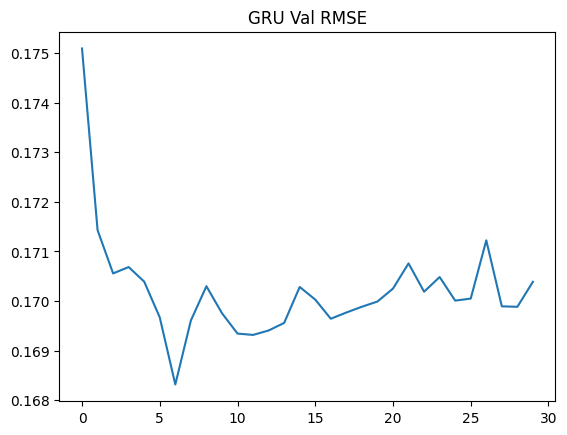

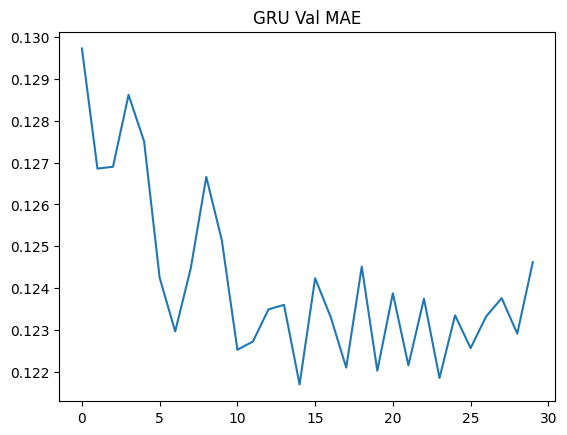

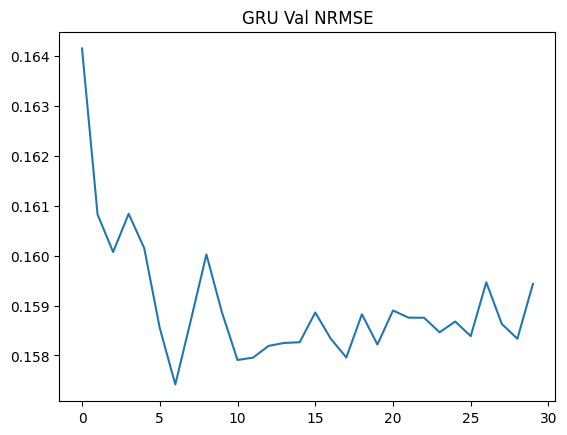

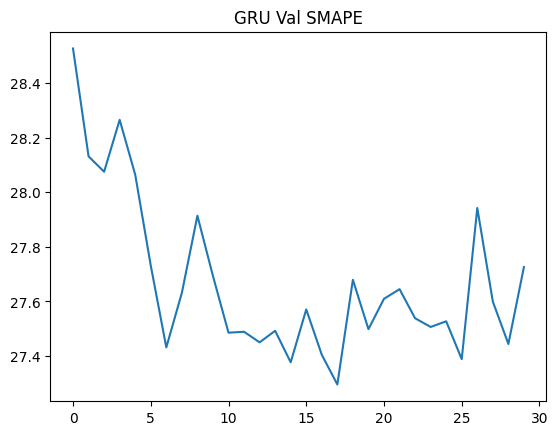

In [10]:
study_d_sid = otimizar_GRU(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='gru_diaria_otimizada_sem_id.keras')

In [ ]:
study_d = otimizar_GRU(X_train_d, 
                        y_train_d, 
                        X_val_d, 
                        y_val_d, 
                        "diária", 
                        inputs_day+1, 
                        outputs_day,
                        path_modelo='gru_diaria_otimizada.keras')

[I 2026-03-10 12:07:33,209] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 12:16:16,471] Trial 0 finished with value: 0.054315656423568726 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.12235538230555863, 'gru_units': 73}. Best is trial 0 with value: 0.054315656423568726.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 12:22:00,917] Trial 1 finished with value: 0.05461956188082695 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.3592900955266286, 'gru_units': 91}. Best is trial 0 with value: 0.054315656423568726.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 16:09:57,144] Trial 18 finished with value: 0.0517883226275444 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.15934442271761623, 'gru_units': 89}. Best is trial 11 with value: 0.05129585042595863.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-10 16:31:47,765] Trial 19 finished with value: 0.05158064514398575 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.2344269170484726, 'gru_units': 126}. Best is trial 11 with value: 0.05129585042595863.



Melhor NRMSE: 0.05129585042595863
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.23200401989248848, 'gru_units': 125}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.06664243340492249   val:0.06513845175504684            
MAE:
    teste:0.03866652771830559   val:0.0345926359295845            
NRMSE:
  teste:0.06545303761959076   val:0.051436156034469604            
SMAPE:
  teste:41.97629928588867   val:39.145503997802734


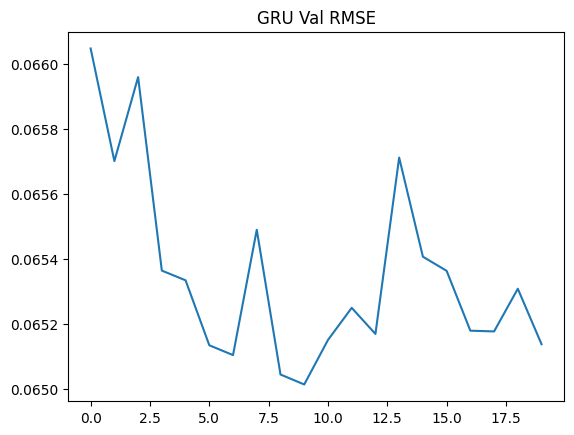

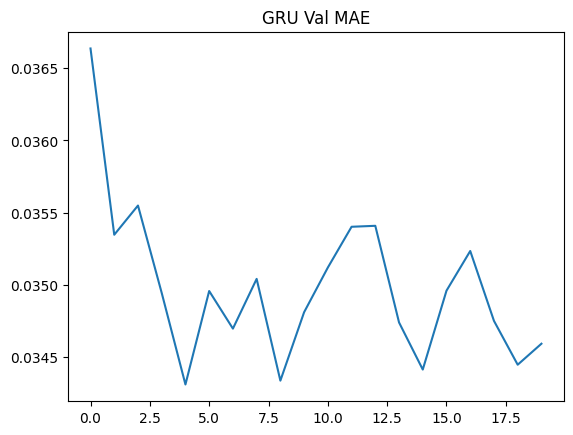

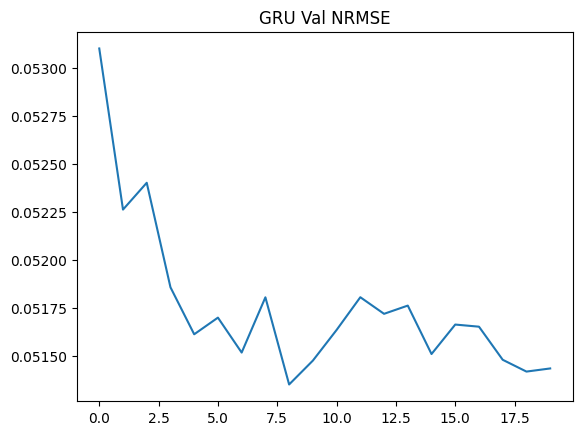

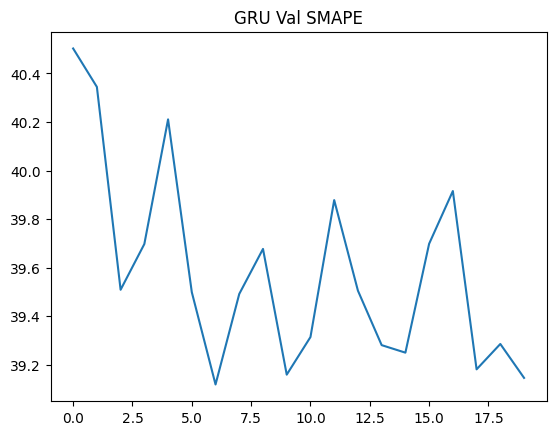

In [13]:
study_h_sid = otimizar_GRU(X_train_h[:,1:], 
                       y_train_h, 
                       X_val_h[:,1:], 
                       y_val_h, 
                       "horária", 
                       inputs_hour,
                       outputs_hour,
                       path_modelo= 'gru_horaria_otimizada_sem_id.keras')

In [ ]:
study_h = otimizar_GRU(X_train_h, 
                       y_train_h, 
                       X_val_h, 
                       y_val_h, 
                       "horária", 
                       inputs_hour+1,
                       outputs_hour,
                       path_modelo= 'gru_horaria_otimizada.keras')

[I 2026-03-08 12:29:03,592] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 12:43:32,191] Trial 0 finished with value: 0.053839121013879776 and parameters: {'batch_size': 16, 'epochs': 50, 'dropout_rate': 0.43514317372010325, 'gru_units': 38}. Best is trial 0 with value: 0.053839121013879776.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 12:46:53,962] Trial 1 finished with value: 0.053716111928224564 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.39820049844988603, 'gru_units': 78}. Best is trial 1 with value: 0.053716111928224564.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 15:45:28,367] Trial 18 finished with value: 0.05327552184462547 and parameters: {'batch_size': 16, 'epochs': 50, 'dropout_rate': 0.25956335507710704, 'gru_units': 89}. Best is trial 17 with value: 0.052590757608413696.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 15:48:43,602] Trial 19 finished with value: 0.05541747808456421 and parameters: {'batch_size': 64, 'epochs': 40, 'dropout_rate': 0.32372068530860193, 'gru_units': 68}. Best is trial 17 with value: 0.052590757608413696.



Melhor NRMSE: 0.052590757608413696
Melhores parâmetros: {'batch_size': 16, 'epochs': 40, 'dropout_rate': 0.2368420652728273, 'gru_units': 107}


[I 2026-03-11 12:14:33,469] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:15:15,379] Trial 0 finished with value: 0.16384625434875488 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.3732663027084887, 'rnn_units': 49}. Best is trial 0 with value: 0.16384625434875488.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:15:46,064] Trial 1 finished with value: 0.1667569875717163 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.3142835947331143, 'rnn_units': 66}. Best is trial 0 with value: 0.16384625434875488.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:23:01,552] Trial 18 finished with value: 0.16545821726322174 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.14295742973399447, 'rnn_units': 80}. Best is trial 12 with value: 0.16348589956760406.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:23:44,449] Trial 19 finished with value: 0.1634034514427185 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.1482807508794411, 'rnn_units': 126}. Best is trial 19 with value: 0.1634034514427185.



Melhor NRMSE: 0.1634034514427185
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.1482807508794411, 'rnn_units': 126}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.16753913462162018   val:0.1748548150062561                
MAE:
    teste:0.1272725611925125   val:0.13047267496585846                
NRMSE:
  teste:0.16352954506874084   val:0.16416889429092407                
SMAPE:
  teste:26.264907836914062   val:28.597862243652344


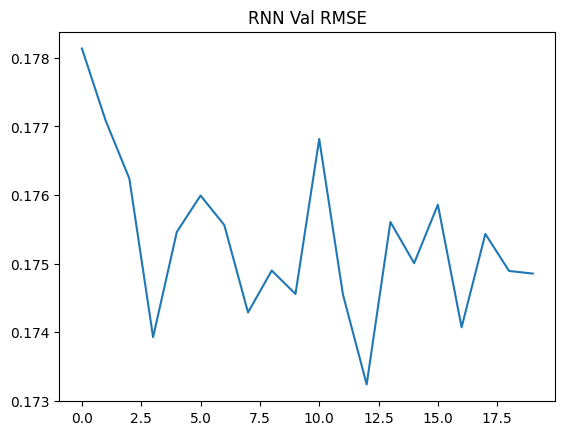

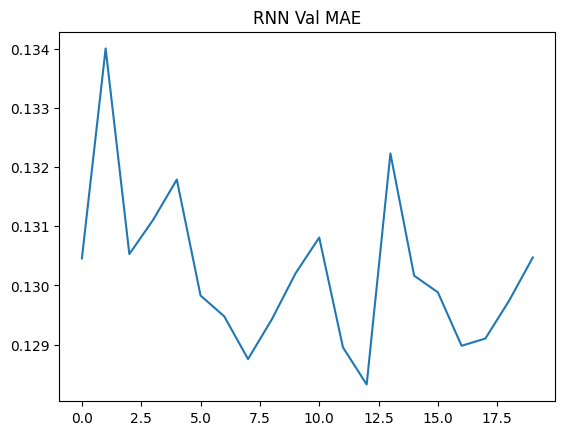

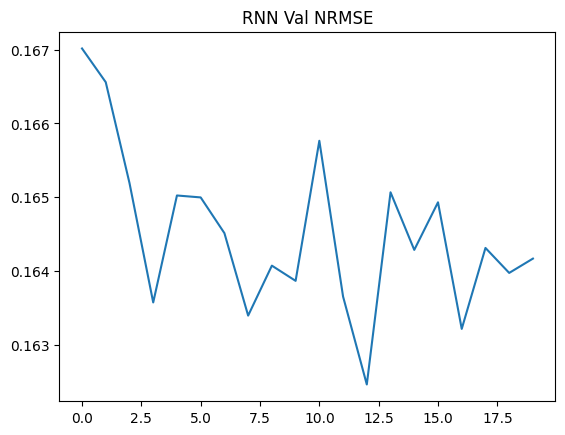

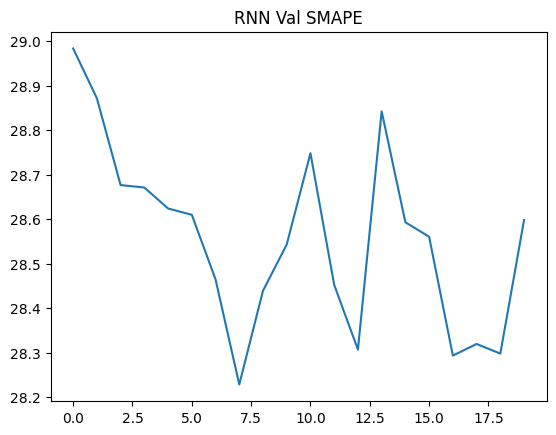

In [35]:
rnn_study_d_sid = otimizar_RNN(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='rnn_diaria_otimizada_sem_id.keras')

[I 2026-03-11 12:02:59,431] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:03:15,843] Trial 0 finished with value: 0.1717298924922943 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.4239314519816536, 'rnn_units': 40}. Best is trial 0 with value: 0.1717298924922943.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:03:58,629] Trial 1 finished with value: 0.16706883907318115 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4866081722492681, 'rnn_units': 95}. Best is trial 1 with value: 0.16706883907318115.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:13:07,448] Trial 18 finished with value: 0.16502588987350464 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.24567468142445983, 'rnn_units': 66}. Best is trial 9 with value: 0.16216875612735748.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:13:52,361] Trial 19 finished with value: 0.16198229789733887 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.15104423182253793, 'rnn_units': 85}. Best is trial 19 with value: 0.16198229789733887.



Melhor NRMSE: 0.16198229789733887
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.15104423182253793, 'rnn_units': 85}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.1707954853773117   val:0.17285600304603577                
MAE:
    teste:0.13054491579532623   val:0.12533079087734222                
NRMSE:
  teste:0.16676627099514008   val:0.1620478332042694                
SMAPE:
  teste:26.92116355895996   val:27.887861251831055


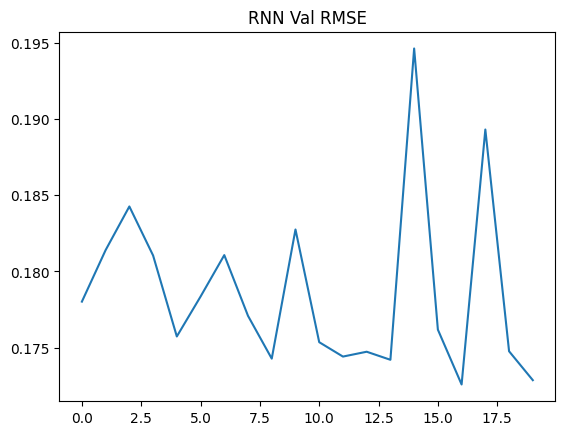

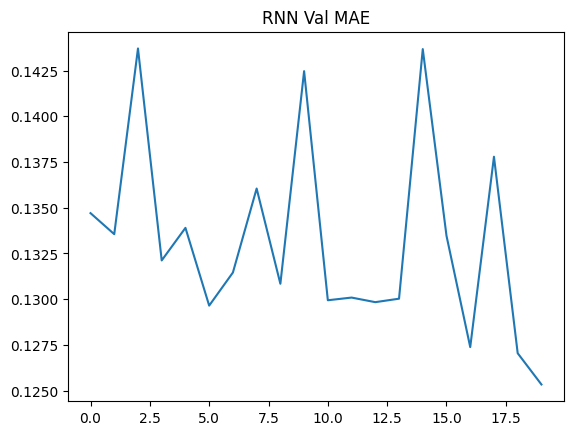

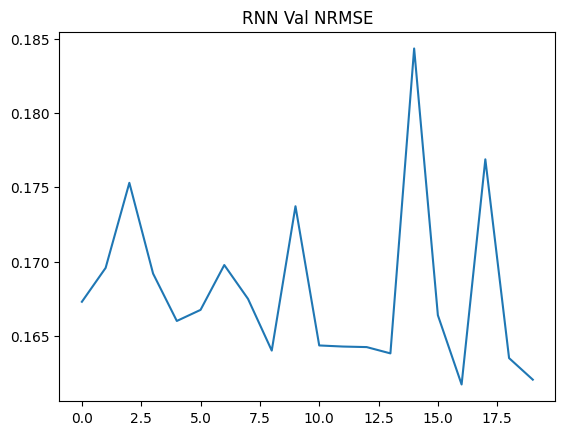

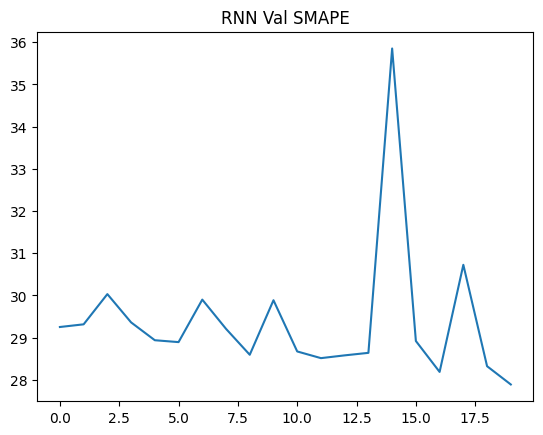

In [34]:
rnn_study_d = otimizar_RNN(X_train_d, 
                        y_train_d, 
                        X_val_d, 
                        y_val_d, 
                        "diária", 
                        inputs_day+1, 
                        outputs_day,
                        path_modelo='rnn_diaria_otimizada.keras')

[I 2026-03-11 12:24:25,490] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:28:26,356] Trial 0 finished with value: 0.057179614901542664 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.2100092867154283, 'rnn_units': 32}. Best is trial 0 with value: 0.057179614901542664.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 12:34:45,904] Trial 1 finished with value: 0.0575902946293354 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.3700824662817681, 'rnn_units': 65}. Best is trial 0 with value: 0.057179614901542664.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 15:20:59,012] Trial 18 finished with value: 0.055364590138196945 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.31368407389705094, 'rnn_units': 53}. Best is trial 16 with value: 0.055070389062166214.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 15:35:47,600] Trial 19 finished with value: 0.05547574162483215 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.2551694046774443, 'rnn_units': 48}. Best is trial 16 with value: 0.055070389062166214.



Melhor NRMSE: 0.055070389062166214
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.2656984833297884, 'rnn_units': 55}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.07270202040672302   val:0.06799176335334778                
MAE:
    teste:0.04428555816411972   val:0.03855680301785469                
NRMSE:
  teste:0.07156803458929062   val:0.05524425581097603                
SMAPE:
  teste:45.28523254394531   val:42.160953521728516


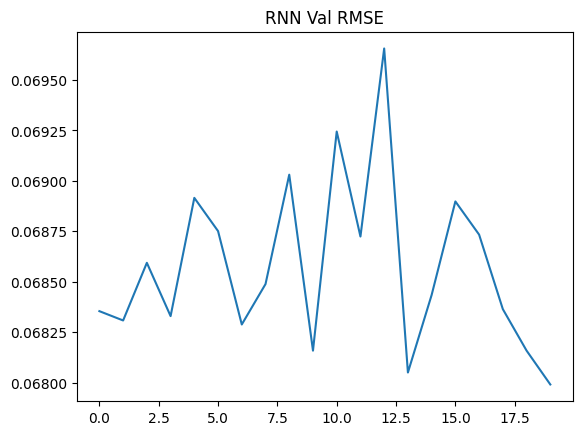

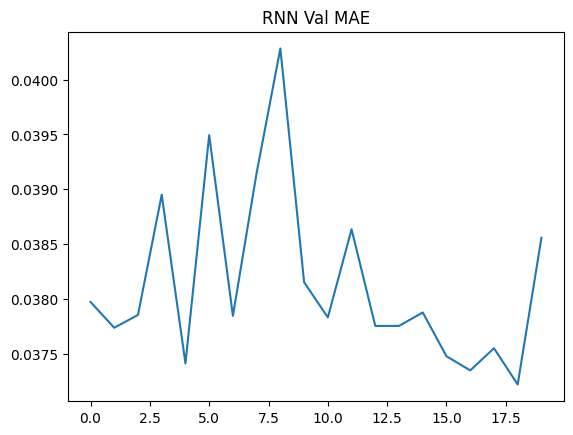

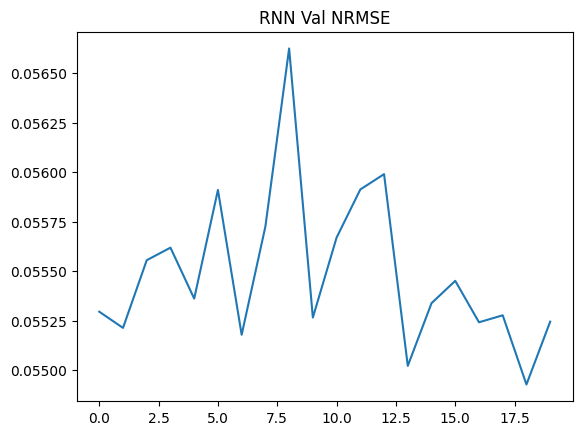

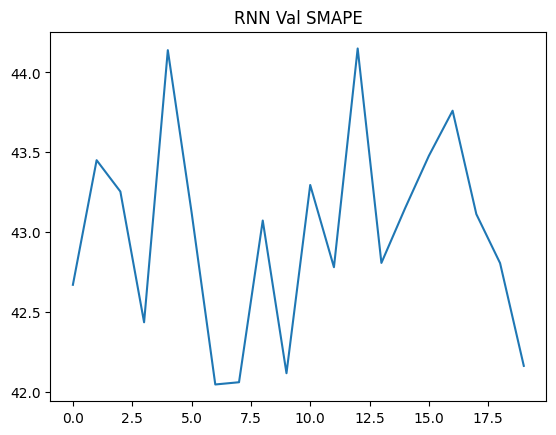

In [36]:
rnn_study_h_sem_id = otimizar_RNN(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:], 
                          y_val_h, 
                          "horária", 
                          inputs_hour,
                          outputs_hour,
                          path_modelo= ('rnn_horaria_otimizada_sem_id.keras')
    
)

[I 2026-03-11 15:50:10,632] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 16:01:08,576] Trial 0 finished with value: 0.05732583627104759 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.3963504255796704, 'rnn_units': 39}. Best is trial 0 with value: 0.05732583627104759.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 16:13:15,753] Trial 1 finished with value: 0.05737536773085594 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.1154539389042884, 'rnn_units': 108}. Best is trial 0 with value: 0.05732583627104759.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 19:34:35,733] Trial 18 finished with value: 0.05920702591538429 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.44035204146310414, 'rnn_units': 44}. Best is trial 4 with value: 0.05676921084523201.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 19:43:09,791] Trial 19 finished with value: 0.0592099130153656 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.3673296124168392, 'rnn_units': 128}. Best is trial 4 with value: 0.05676921084523201.



Melhor NRMSE: 0.05676921084523201
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.470698131925946, 'rnn_units': 126}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.07801507413387299   val:0.072028249502182                
MAE:
    teste:0.05097087845206261   val:0.04678900167346001                
NRMSE:
  teste:0.07696525007486343   val:0.06141923740506172                
SMAPE:
  teste:49.52189636230469   val:45.876380920410156


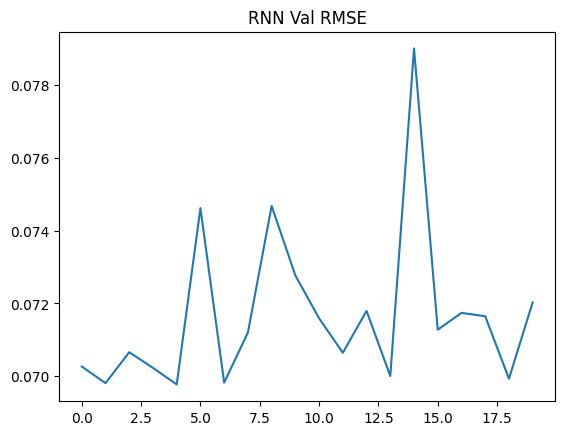

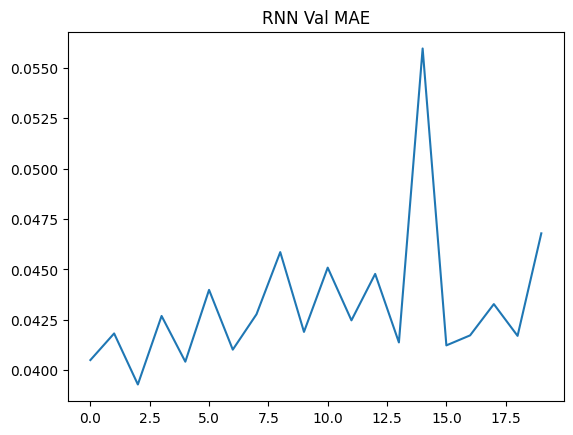

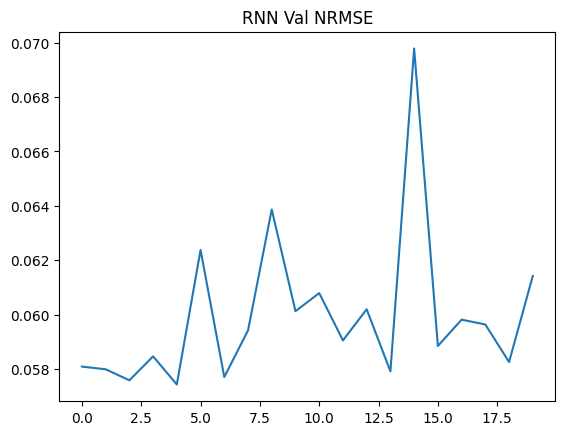

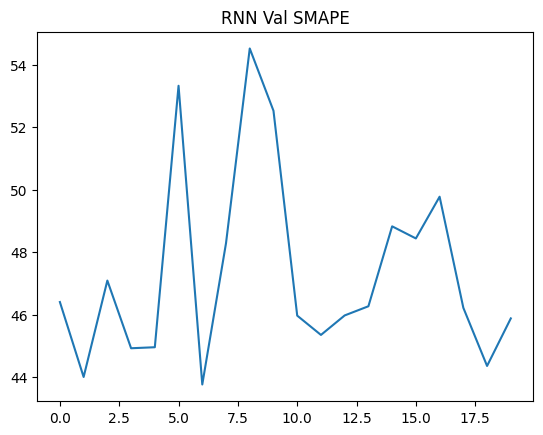

In [37]:
rnn_study_h = otimizar_RNN(
                          X_train_h, 
                          y_train_h, 
                          X_val_h, 
                          y_val_h, 
                          "horária", 
                          inputs_hour+1,
                          outputs_hour,
                          path_modelo= ('rnn_horaria_otimizada_sem_id.keras')
)

[I 2026-03-11 20:00:01,791] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:00:33,510] Trial 0 finished with value: 0.1623040735721588 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.22075544749918802, 'lstm_units': 37}. Best is trial 0 with value: 0.1623040735721588.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:00:55,725] Trial 1 finished with value: 0.16499808430671692 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.3303455966809999, 'lstm_units': 84}. Best is trial 0 with value: 0.1623040735721588.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:09:01,878] Trial 18 finished with value: 0.15865913033485413 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.4980949050121251, 'lstm_units': 33}. Best is trial 8 with value: 0.15780316293239594.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:09:46,408] Trial 19 finished with value: 0.15946680307388306 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4190405203300016, 'lstm_units': 49}. Best is trial 8 with value: 0.15780316293239594.



Melhor NRMSE: 0.15780316293239594
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.30494559354849515, 'lstm_units': 35}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.15744514763355255   val:0.17019547522068024            
MAE:
    teste:0.11736654490232468   val:0.12515734136104584            
NRMSE:
  teste:0.15289001166820526   val:0.15928901731967926            
SMAPE:
  teste:25.16774559020996   val:27.633922576904297


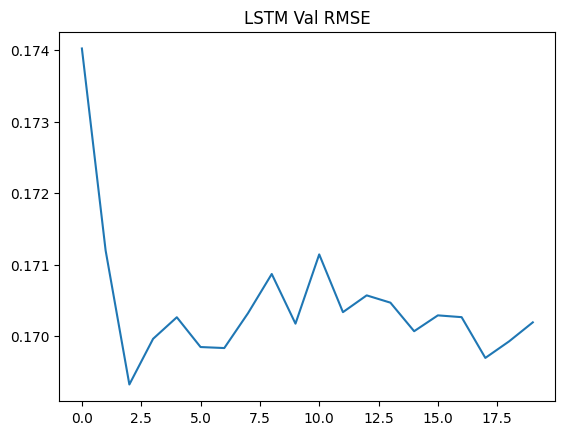

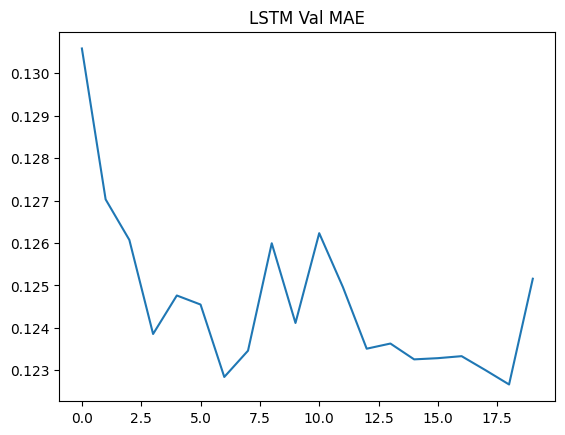

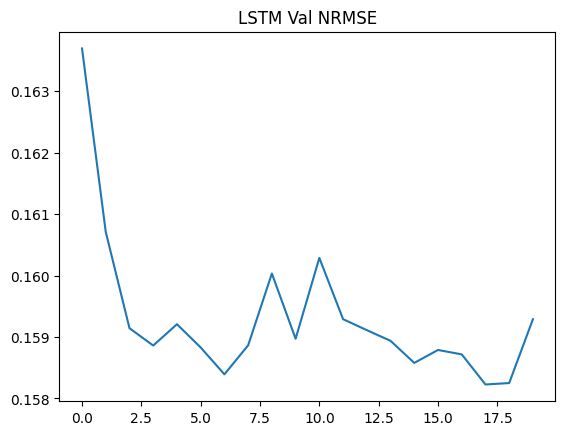

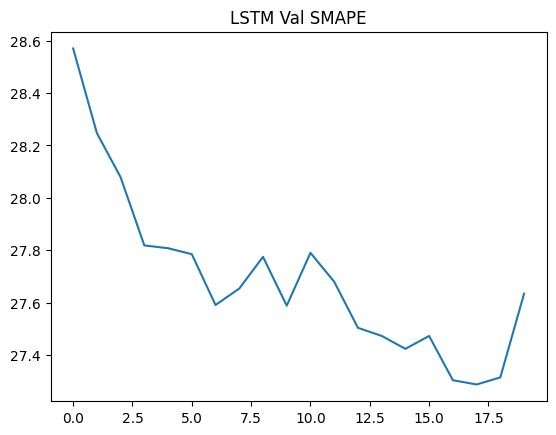

In [40]:
lstm_study_d_sid = otimizar_LSTM(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='lstm_diaria_otimizada_sem_id.keras'
                        )

[I 2026-03-11 20:10:24,565] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:11:47,127] Trial 0 finished with value: 0.1634022742509842 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.15980893943695793, 'lstm_units': 110}. Best is trial 0 with value: 0.1634022742509842.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:12:10,903] Trial 1 finished with value: 0.164828360080719 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.4853763821976457, 'lstm_units': 104}. Best is trial 0 with value: 0.1634022742509842.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:21:32,620] Trial 18 finished with value: 0.16106747090816498 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.22204628283421946, 'lstm_units': 40}. Best is trial 10 with value: 0.16052716970443726.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:22:47,177] Trial 19 finished with value: 0.15926241874694824 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.1723553408367834, 'lstm_units': 89}. Best is trial 19 with value: 0.15926241874694824.



Melhor NRMSE: 0.15926241874694824
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.1723553408367834, 'lstm_units': 89}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.16245120763778687   val:0.17252880334854126            
MAE:
    teste:0.1226717159152031   val:0.12810297310352325            
NRMSE:
  teste:0.15825429558753967   val:0.16240060329437256            
SMAPE:
  teste:25.822240829467773   val:28.13339614868164


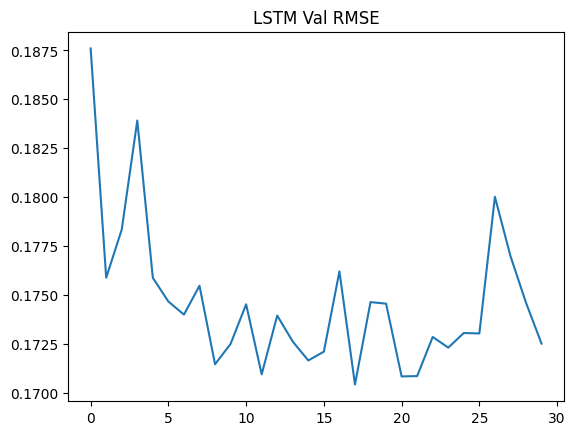

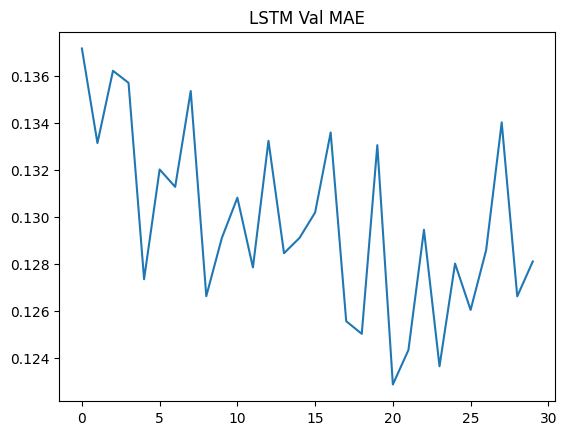

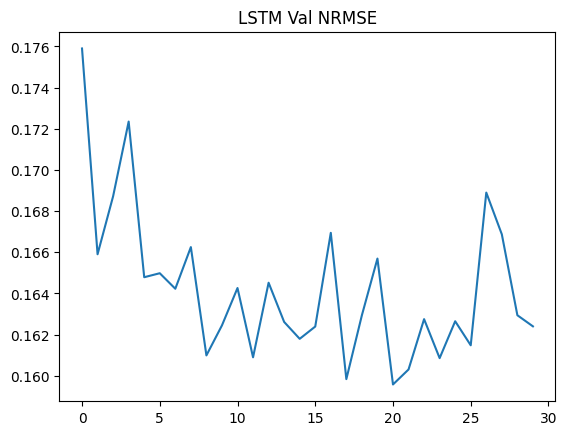

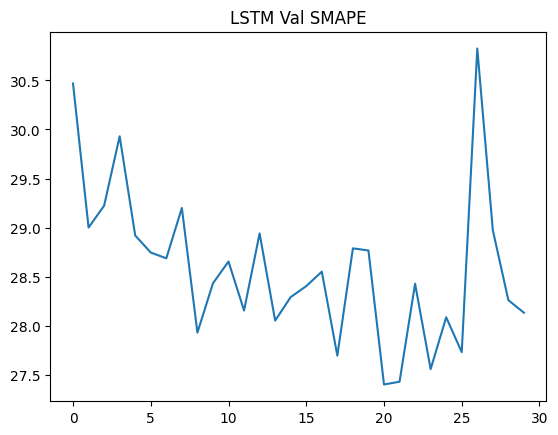

In [41]:
lstm_study_d = otimizar_LSTM(X_train_d, 
                        y_train_d, 
                        X_val_d, 
                        y_val_d, 
                        "diária", 
                        inputs_day+1, 
                        outputs_day,
                        path_modelo='lstm_diaria_otimizada.keras'
                        )

[I 2026-03-11 20:24:04,637] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:35:27,418] Trial 0 finished with value: 0.052036695182323456 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.33548712867644187, 'lstm_units': 82}. Best is trial 0 with value: 0.052036695182323456.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-11 20:48:43,654] Trial 1 finished with value: 0.05333587899804115 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.48471367628419404, 'lstm_units': 103}. Best is trial 0 with value: 0.052036695182323456.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 00:27:26,672] Trial 18 finished with value: 0.05200572311878204 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.13570057807497282, 'lstm_units': 115}. Best is trial 13 with value: 0.05127556249499321.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 00:39:11,277] Trial 19 finished with value: 0.051785361021757126 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.22088916928224467, 'lstm_units': 71}. Best is trial 13 with value: 0.05127556249499321.



Melhor NRMSE: 0.05127556249499321
Melhores parâmetros: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.12232294709305555, 'lstm_units': 123}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.06590858101844788   val:0.06615141034126282            
MAE:
    teste:0.03775922954082489   val:0.03467020019888878            
NRMSE:
  teste:0.06472348421812057   val:0.051982391625642776            
SMAPE:
  teste:40.87458038330078   val:39.511566162109375


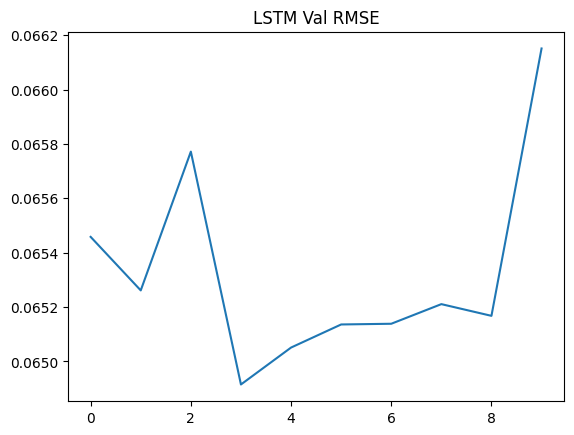

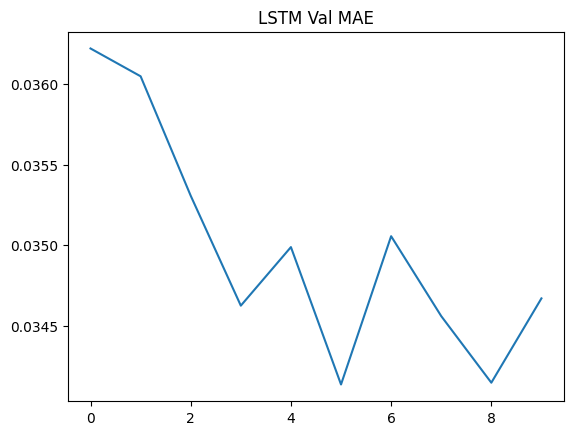

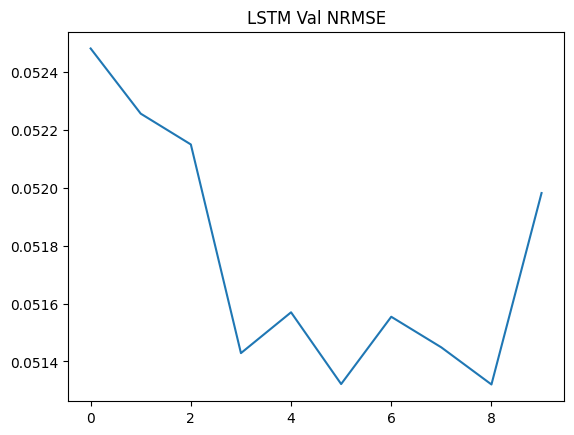

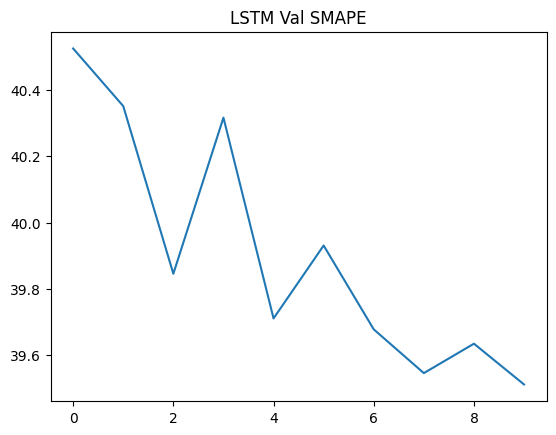

In [42]:
lstm_study_h_sid = otimizar_LSTM(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:],
                            y_val_h,
                            "horária",
                            inputs_hour,
                            outputs_hour,
                            path_modelo= 'lstm_horaria_otimizada_sem_id.keras'
)

In [ ]:
lstm_study_h = otimizar_LSTM(X_train_h,
                            y_train_h,
                            X_val_h,
                            y_val_h,
                            "horária",
                            inputs_hour+1,
                            outputs_hour,
                            path_modelo='lstm_horaria_otimizada.keras'
                            )

[I 2026-03-12 00:51:23,831] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 00:51:24,020] Trial 0 pruned. 


criando modelo...


[I 2026-03-12 00:51:24,215] Trial 1 pruned. 


...

[I 2026-03-12 00:51:27,457] Trial 17 pruned. 


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-12 00:51:27,752] Trial 18 pruned. 
[I 2026-03-12 00:51:27,944] Trial 19 pruned. 


criando modelo...
compilando modelo...
treinando modelo...


ValueError: No trials are completed yet.

## Carregando modelos

In [44]:
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

def avaliar_modelo(y_real, y_previsto, verbose = False):
    mse = mean_squared_error(y_real, y_previsto)
    rmse = math.sqrt(mse)
    nrmse = rmse / (max(y_real) - min(y_real))
    mae = mean_absolute_error(y_real, y_previsto)
    _smape = smape(y_real, y_previsto) 
    if verbose:
        print(f"--- Desempenho: ---")
        print(f"RMSE (Erro Médio): {rmse:.4f}")
        print(f"MAE  (Erro Absoluto): {mae:.4f}")
        print(f"SMAPE: {_smape:.4f}")
        print(f"NRMSE: {nrmse:.4f}")
        print("-" * 30)
    return np.array([rmse, mae, nrmse, _smape])

def comparar_desempeho_granularidade(X_test_d, X_test_h, y_test_d, y_test_h, MODELO_d, MODELO_h):
    print("Carregando modelos...")
    y_pred_d = MODELO_d.predict(X_test_d)
    y_pred_h = MODELO_h.predict(X_test_h)
    
    print(f"Desempenho do modelo para granularidade diária:")
    resultado_d = avaliar_modelo(y_test_d.flatten(), y_pred_d.flatten(), verbose=True)
    
    print(f"Desempenho do modelo para granularidade horária:")
    resultado_h = avaliar_modelo(y_test_h.flatten(), y_pred_h.flatten(), verbose=True)
    
    return [resultado_d, resultado_h]


def avaliar_modelo_inst(inst:list,X_test_d, X_test_h, y_test_d, y_test_h, modelo_d, modelo_h):
    resultados = {
        "instituição": [],
        "granularidade:": [],
        "MAE": [],
        "RMSE": [],
        "NRMSE": [],
        "SMAPE": []
    }
    def separar_dados_por_instituicao(inst, X_test, y_test):
        idx = np.where(X_test[:,0] == inst)[0]
        X_test_i = X_test[idx]
        y_test_i = y_test[idx]
        return X_test_i, y_test_i
    for i in inst:
        print(f"\n##############################\n \
Avaliando instituição {i}... \
                \n##############################\n")
        X_test_d_i, y_test_d_i = separar_dados_por_instituicao(i, X_test_d, y_test_d)
        X_test_h_i, y_test_h_i = separar_dados_por_instituicao(i, X_test_h, y_test_h)
        resultado = comparar_desempeho_granularidade(X_test_d_i, X_test_h_i, y_test_d_i, y_test_h_i, modelo_d, modelo_h)
        resultados["instituição"].append(i)
        resultados["granularidade:"].append("diária")
        resultados["MAE"].append(resultado[0][1])
        resultados["RMSE"].append(resultado[0][0])
        resultados["NRMSE"].append(resultado[0][2])
        resultados["SMAPE"].append(resultado[0][3])
        
        resultados["instituição"].append(i)
        resultados["granularidade:"].append("horária")
        resultados["MAE"].append(resultado[1][1])
        resultados["RMSE"].append(resultado[1][0])
        resultados["NRMSE"].append(resultado[1][2])
        resultados["SMAPE"].append(resultado[1][3])
    return pd.DataFrame(resultados)



        
        



In [42]:
gru_diaria = load_model('../../MODELOS/GRU_diaria_otimizada.keras', compile=False)
gru_horaria = load_model('../../MODELOS/GRU_horaria_otimizada.keras', compile=False)
resultado_geral =comparar_desempeho_granularidade(
    X_test_d.reshape((X_test_d.shape[0], 1, X_test_d.shape[1])),
    X_test_h.reshape((X_test_h.shape[0], 1, X_test_h.shape[1])),
    y_test_d[:,0], 
    y_test_h[:,:24], 
    gru_diaria, 
    gru_horaria
    )
#avaliar_modelo_inst(inst_day, X_test_d, X_test_h, y_test_d, y_test_h, gru_diaria, gru_horaria)

Carregando modelos...
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 1s 477us/step
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1494
MAE  (Erro Absoluto): 0.1162
SMAPE: 37.5851
NRMSE: 0.0897
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0600
MAE  (Erro Absoluto): 0.0312
SMAPE: 44.0314
NRMSE: 0.0172
------------------------------


In [51]:
inst_day = list(test_day_wind["id_institution"].unique())

df =avaliar_modelo_inst(inst_day,
                    X_test_d.reshape((X_test_d.shape[0], 1, X_test_d.shape[1])), 
                    X_test_h.reshape((X_test_h.shape[0], 1, X_test_h.shape[1])), 
                    y_test_d[:,0], 
                    y_test_h[:,:24], 
                    gru_diaria, 
                    gru_horaria)

display(df)


##############################
 Avaliando instituição 189...                 
##############################

Carregando modelos...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1357
MAE  (Erro Absoluto): 0.1197
SMAPE: 71.7330
NRMSE: 0.2415
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0243
MAE  (Erro Absoluto): 0.0134
SMAPE: 87.0548
NRMSE: 0.0760
------------------------------

##############################
 Avaliando instituição 68...                 
##############################

Carregando modelos...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1029
MAE  (Erro Absoluto): 0.0847
SMAPE: 26.0066
NRMSE: 0.4237
------------------------------
Desempenho do modelo para gra

,instituição,granularidade:,MAE,RMSE,NRMSE,SMAPE
0,189,diária,0.119681,0.135679,0.241493,71.733047
1,189,horária,0.013440,0.024318,0.075995,87.054756
2,68,diária,0.084707,0.102925,0.423729,26.006598
3,68,horária,0.038114,0.048071,0.140482,15.630311
4,217,diária,0.204103,0.273591,0.217273,44.121128
...,...,...,...,...,...,...
329,76,horária,0.019418,0.038876,0.082688,55.424767
330,118,diária,0.114414,0.136448,0.228537,12.199168
331,118,horária,0.088755,0.115589,0.159500,17.534832
332,104,diária,0.111729,0.136523,0.212420,26.018604


In [66]:
df.to_csv('../../RESULTADOS/avaliacao_por_instituicao.csv', index = False)

In [65]:
df[(df['NRMSE'] >= 1)]

,instituição,granularidade:,MAE,RMSE,NRMSE,SMAPE
90,62,diária,0.115442,0.131275,1.694386,58.937145
108,38,diária,0.084423,0.085504,2.621264,96.992065
174,177,diária,0.090171,0.090763,1.801061,79.380402
296,141,diária,0.091681,0.094684,1.122402,81.725952
308,243,diária,0.080248,0.080248,32605.832031,100.000000
309,243,horária,0.012537,0.014538,7568.569824,99.723816


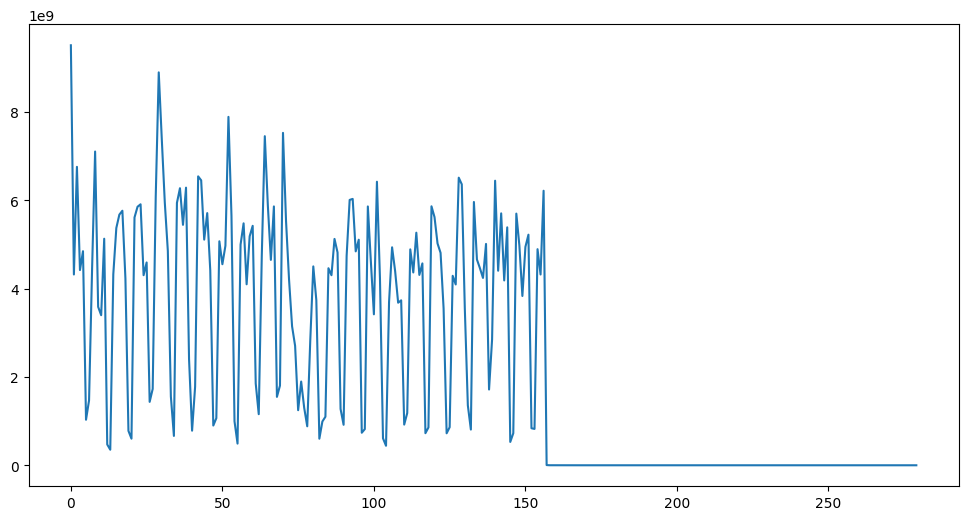

In [93]:
# 1. Filtre o DataFrame uma única vez
df_inst_243 = df_day[df_day['id_institution'] == '243']

# 2. Passe as colunas de tempo (x) e bytes (y) diretamente
plt.figure(figsize=(12, 6))
plt.plot(df_inst_243['id_time'], df_inst_243['n_bytes'])

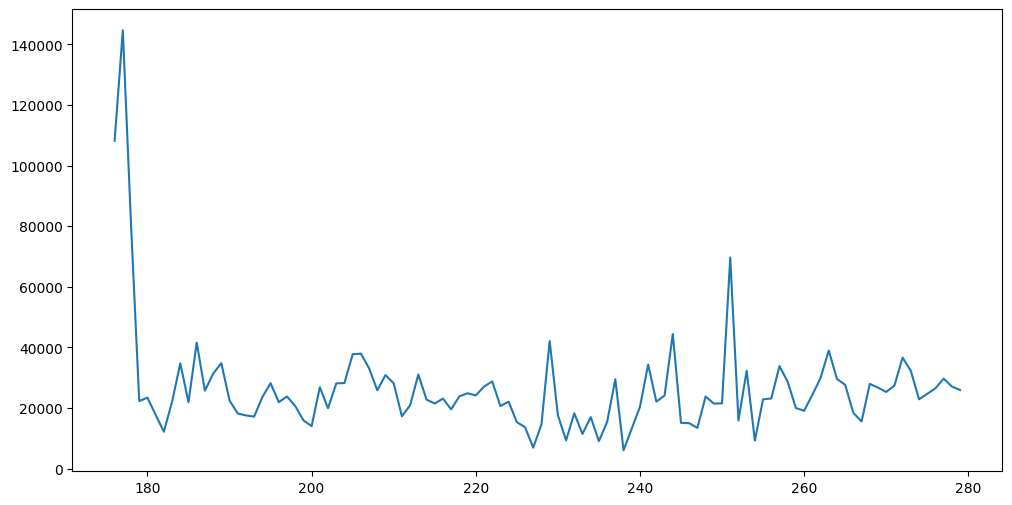

In [91]:
# 2. Passe as colunas de tempo (x) e bytes (y) diretamente
plt.figure(figsize=(12, 6))
plt.plot(df_inst_243[df_inst_243['id_time'] > 175]['id_time'], df_inst_243[df_inst_243['id_time'] > 175]['n_bytes'])

In [79]:
df_inst_243.tail(10)

,id_time,n_bytes,id_institution
72218,270,25309,243
72219,271,27412,243
72220,272,36631,243
72221,273,32279,243
72222,274,22878,243
72223,275,24693,243
72224,276,26496,243
72225,277,29705,243
72226,278,27094,243
72227,279,25954,243


In [54]:
gru_diaria = load_model('../../MODELOS/gru_diaria_otimizada_sem_id.keras', compile=False)
gru_horaria = load_model('../../MODELOS/gru_horaria_otimizada_sem_id.keras', compile=False)
resultado_geral =comparar_desempeho_granularidade(
    X_test_d[:,1:].reshape((X_test_d.shape[0], 1, X_test_d.shape[1]-1)),
    X_test_h[:,1:].reshape((X_test_h.shape[0], 1, X_test_h.shape[1]-1)),
    y_test_d[:,0], 
    y_test_h[:,:24], 
    gru_diaria, 
    gru_horaria
    )

Carregando modelos...
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 2s 574us/step
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1414
MAE  (Erro Absoluto): 0.1062
SMAPE: 35.8341
NRMSE: 0.0850
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0581
MAE  (Erro Absoluto): 0.0293
SMAPE: 42.2442
NRMSE: 0.0167
------------------------------
